In [5]:
from google.colab import files
uploaded = files.upload()

Saving marketing_campaign_dataset.csv to marketing_campaign_dataset.csv


# Digital Marketing Autopsy
## Which Campaign Channels Actually Convert?
### Data Science Portfolio | Lungile Zulu | May 2026

**Business Question:** A marketing manager wants to know which channels, campaign
types and audience segments deliver the best ROI and where budget is being wasted.

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Set chart style
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid', palette='muted')

print("All libraries loaded")

All libraries loaded


In [6]:
# Load the CSV file into a DataFrame
df_full = pd.read_csv('marketing_campaign_dataset.csv')

# Print the overall shape of the dataset (rows, columns)
print(f"Full dataset shape: {df_full.shape}")

# Print the list of column names in the dataset
print(f"\nColumn names:")
print(df_full.columns.tolist())

# Print the first 3 rows of the dataset to preview the data
print(f"\nFirst 3 rows:")
df_full.head(3)

Full dataset shape: (200000, 16)

Column names:
['Campaign_ID', 'Company', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Conversion_Rate', 'Acquisition_Cost', 'ROI', 'Location', 'Language', 'Clicks', 'Impressions', 'Engagement_Score', 'Customer_Segment', 'Date']

First 3 rows:


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03


In [7]:
# Randomly sample 20,000 rows from the full dataset
df = df_full.sample(n=20000, random_state=42).reset_index(drop=True)

# Print the shape of the working dataset (rows, columns)
print(f"Working dataset shape: {df.shape}")

# Print the data types of each column (e.g., int64, float64, object)
print(f"\nColumn types:\n{df.dtypes}")

# Print the number of missing values in each column
print(f"\nMissing values:\n{df.isnull().sum()}")

# Print quick summary statistics for numeric columns (count, mean, std, min, quartiles, max)
print(f"\nQuick stats:")
df.describe()

Working dataset shape: (20000, 16)

Column types:
Campaign_ID           int64
Company              object
Campaign_Type        object
Target_Audience      object
Duration             object
Channel_Used         object
Conversion_Rate     float64
Acquisition_Cost     object
ROI                 float64
Location             object
Language             object
Clicks                int64
Impressions           int64
Engagement_Score      int64
Customer_Segment     object
Date                 object
dtype: object

Missing values:
Campaign_ID         0
Company             0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Conversion_Rate     0
Acquisition_Cost    0
ROI                 0
Location            0
Language            0
Clicks              0
Impressions         0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64

Quick stats:


,Campaign_ID,Conversion_Rate,ROI,Clicks,Impressions,Engagement_Score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000
mean,100368.134850,0.080213,5.003959,552.453800,5498.46425,5.470300
std,57932.619847,0.040552,1.741273,259.317363,2590.91376,2.879224
min,5.000000,0.010000,2.000000,100.000000,1000.00000,1.000000
25%,49712.250000,0.050000,3.490000,327.000000,3266.75000,3.000000
50%,100392.500000,0.080000,5.000000,553.000000,5489.50000,5.000000
75%,151101.250000,0.110000,6.520000,776.000000,7736.00000,8.000000
max,199998.000000,0.150000,8.000000,1000.000000,10000.00000,10.000000


The full dataset contains ~200,000 rows. I sampled 20,000 rows using a fixed
random seed (42) to ensure reproducibility while keeping the analysis manageable.
The sample preserves the distribution of campaign types and channels.

In [9]:
# Fix Acquisition_Cost : remove $ sign and convert from text to number

# Check what it currently looks like
print("Before cleaning:")
print(df['Acquisition_Cost'].dtype)
print(df['Acquisition_Cost'].head(5))

# Strip the dollar sign and any spaces, then convert to float
df['Acquisition_Cost'] = df['Acquisition_Cost'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).str.strip().astype(float)

# Confirm it worked
print("\nAfter cleaning:")
print(df['Acquisition_Cost'].dtype)
print(df['Acquisition_Cost'].head(5))
print(f"\nMin: {df['Acquisition_Cost'].min()}")
print(f"Max: {df['Acquisition_Cost'].max()}")
print(f"Mean: {df['Acquisition_Cost'].mean():.2f}")

Before cleaning:
float64
0     7089.0
1    13500.0
2     9687.0
3     8760.0
4    18925.0
Name: Acquisition_Cost, dtype: float64


AttributeError: Can only use .str accessor with string values!

In [10]:
# Reload the database with the cleaned data
df.to_sql('campaigns', conn, if_exists='replace', index=False)
print("Database reloaded with cleaned Acquisition_Cost")

NameError: name 'conn' is not defined

In [28]:
# Check how evenly the key categories are represented in your sample
print("Campaign Type breakdown:")
print(df['Campaign_Type'].value_counts())

print("\nChannels Used breakdown:")
print(df['Channel_Used'].value_counts())

print("\nCustomer Segment breakdown:")
print(df['Customer_Segment'].value_counts())

Campaign Type breakdown:
Campaign_Type
Email           4060
Social Media    4002
Display         3997
Search          3990
Influencer      3951
Name: count, dtype: int64

Channels Used breakdown:
Channel_Used
Email         3389
Website       3375
YouTube       3369
Google Ads    3353
Instagram     3345
Facebook      3169
Name: count, dtype: int64

Customer Segment breakdown:
Customer_Segment
Outdoor Adventurers    4058
Fashionistas           4054
Tech Enthusiasts       3999
Health & Wellness      3961
Foodies                3928
Name: count, dtype: int64


## SQL Analysis
Loading data into a SQLite database and running business queries.

In [29]:
# Create a SQLite database file in Colab's working directory
conn = sqlite3.connect('marketing_campaigns.db')

# Load your 20,000-row dataframe into a SQL table called 'campaigns'
df.to_sql('campaigns', conn, if_exists='replace', index=False)

# Verify it loaded correctly
check = pd.read_sql("SELECT COUNT(*) as total_rows FROM campaigns", conn)
print("Database created: marketing_campaigns.db")
print(f"Table 'campaigns' loaded with {check['total_rows'][0]} rows")

# Preview the table structure
preview = pd.read_sql("SELECT * FROM campaigns LIMIT 5", conn)
print("\nFirst 5 rows from database:")
preview

Database created: marketing_campaigns.db
Table 'campaigns' loaded with 20000 rows

First 5 rows from database:


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,119738,Innovate Industries,Influencer,Women 35-44,60 days,Email,0.08,7089.0,6.34,New York,German,692,8092,2,Tech Enthusiasts,2021-01-18
1,72273,TechCorp,Influencer,Women 25-34,60 days,Email,0.03,13500.0,2.75,Los Angeles,German,269,8825,4,Foodies,2021-01-03
2,158155,TechCorp,Email,Women 35-44,45 days,Google Ads,0.07,9687.0,3.72,Houston,Spanish,840,9038,5,Outdoor Adventurers,2021-04-20
3,65427,Alpha Innovations,Display,All Ages,30 days,Facebook,0.09,8760.0,5.45,Houston,English,616,3303,7,Health & Wellness,2021-04-02
4,30075,TechCorp,Social Media,Women 25-34,15 days,Google Ads,0.11,18925.0,6.72,Houston,English,538,7364,1,Fashionistas,2021-05-25


# SQL Query 1 — Conversion Rate by Campaign Type

In [30]:
# Define a SQL query as a multi-line string
query1 = """
SELECT
    Campaign_Type,                                -- Grouping column: type of campaign
    COUNT(*)                                    AS num_campaigns,          -- Count how many campaigns per type
    ROUND(AVG(Conversion_Rate), 4)              AS avg_conversion_rate,    -- Average conversion rate, rounded to 4 decimals
    ROUND(AVG(ROI), 4)                          AS avg_roi,                -- Average return on investment, rounded to 4 decimals
    ROUND(AVG(Acquisition_Cost), 2)             AS avg_acquisition_cost,   -- Average acquisition cost, rounded to 2 decimals
    ROUND(AVG(Engagement_Score), 2)             AS avg_engagement_score    -- Average engagement score, rounded to 2 decimals
FROM campaigns
GROUP BY Campaign_Type                          -- Aggregate results by campaign type
ORDER BY avg_conversion_rate DESC;              -- Sort results by conversion rate (highest first)
"""

# Execute the SQL query against the database connection and load results into a DataFrame
df_q1 = pd.read_sql(query1, conn)

# Print a title for clarity
print("QUERY 1: Performance by Campaign Type")

# Print the full DataFrame as a string (no row index shown)
print(df_q1.to_string(index=False))


QUERY 1: Performance by Campaign Type
Campaign_Type  num_campaigns  avg_conversion_rate  avg_roi  avg_acquisition_cost  avg_engagement_score
 Social Media           4002               0.0819   5.0184              12481.70                  5.47
   Influencer           3951               0.0804   5.0057              12517.21                  5.44
       Search           3990               0.0801   4.9990              12547.31                  5.48
        Email           4060               0.0801   4.9972              12466.58                  5.44
      Display           3997               0.0786   4.9995              12535.34                  5.52


**Hypothesis 1:** Email campaigns will have the highest conversion rate.

**Result:** The analysis reveals that Social Media campaigns achieve the highest average conversion rate (0.0819), closely followed by Influencer campaigns (0.0804). Email campaigns, with an average conversion rate of 0.0801, do not lead in this metric.

**Conclusion:** This finding challenges the initial hypothesis, as both Social Media and Influencer campaign types demonstrate higher average conversion rates compared to Email campaigns. This suggests a need to re-evaluate the perceived effectiveness of Email campaigns relative to other channels.

# SQL Query 2 — Performance by Channel

In [31]:
# Define a SQL query as a multi-line string
query2 = """
SELECT
    Channel_Used,                               -- Grouping column: marketing channels used in campaigns
    COUNT(*)                                    AS num_campaigns,          -- Count how many campaigns used each channel
    ROUND(AVG(Conversion_Rate), 4)              AS avg_conversion_rate,    -- Average conversion rate per channel, rounded to 4 decimals
    ROUND(AVG(ROI), 4)                          AS avg_roi,                -- Average return on investment per channel, rounded to 4 decimals
    ROUND(AVG(Acquisition_Cost), 2)             AS avg_cost,               -- Average acquisition cost per channel, rounded to 2 decimals
    SUM(Clicks)                                 AS total_clicks,           -- Total clicks generated by campaigns in each channel
    SUM(Impressions)                            AS total_impressions,      -- Total impressions generated by campaigns in each channel
    ROUND(SUM(Clicks) * 100.0 /
          NULLIF(SUM(Impressions), 0), 2)       AS click_through_rate_pct  -- CTR = (Clicks ÷ Impressions) × 100, rounded to 2 decimals
FROM campaigns
GROUP BY Channel_Used                          -- Aggregate results by channel
ORDER BY avg_roi DESC;                          -- Sort channels by ROI (highest first)
"""

# Execute the SQL query against the database connection and load results into a DataFrame
df_q2 = pd.read_sql(query2, conn)

# Print a title for clarity
print("QUERY 2: Performance by Channel")

# Print the full DataFrame as a string (no row index shown)
print(df_q2.to_string(index=False))

QUERY 2: Performance by Channel
Channel_Used  num_campaigns  avg_conversion_rate  avg_roi  avg_cost  total_clicks  total_impressions  click_through_rate_pct
     YouTube           3369               0.0807   5.0427  12426.46       1849994           18613837                    9.94
       Email           3389               0.0799   5.0376  12630.85       1893061           18411492                   10.28
     Website           3375               0.0801   5.0048  12545.96       1886891           18584863                   10.15
  Google Ads           3353               0.0806   5.0028  12493.32       1830111           18576438                    9.85
    Facebook           3169               0.0807   4.9718  12439.67       1734529           17421620                    9.96
   Instagram           3345               0.0794   4.9616  12515.52       1854490           18361035                   10.10


# SQL Query 3 — Audience Segment Analysis


In [32]:
# Define a SQL query as a multi-line string
query3 = """
SELECT
    Customer_Segment,                             -- Grouping column: audience/customer segment
    COUNT(*)                                    AS num_campaigns,          -- Number of campaigns targeting each segment
    ROUND(AVG(Conversion_Rate), 4)              AS avg_conversion_rate,    -- Average conversion rate per segment, rounded to 4 decimals
    ROUND(AVG(ROI), 4)                          AS avg_roi,                -- Average return on investment per segment, rounded to 4 decimals
    ROUND(AVG(Engagement_Score), 2)             AS avg_engagement          -- Average engagement score per segment, rounded to 2 decimals
FROM campaigns
GROUP BY Customer_Segment                        -- Aggregate results by customer segment
ORDER BY avg_conversion_rate DESC;               -- Sort segments by conversion rate (highest first)
"""

# Execute the SQL query against the database connection and load results into a DataFrame
df_q3 = pd.read_sql(query3, conn)

# Print a title for clarity
print("QUERY 3: Performance by Audience Segment")

# Print the full DataFrame as a string (no row index shown)
print(df_q3.to_string(index=False))


QUERY 3: Performance by Audience Segment
   Customer_Segment  num_campaigns  avg_conversion_rate  avg_roi  avg_engagement
Outdoor Adventurers           4058               0.0807   4.9685            5.44
   Tech Enthusiasts           3999               0.0805   5.0206            5.50
  Health & Wellness           3961               0.0805   4.9827            5.43
            Foodies           3928               0.0797   5.0363            5.51
       Fashionistas           4054               0.0797   5.0124            5.48


# SQL Query 4 — Best combinations

In [33]:
# Define a SQL query as a multi-line string
query4 = """
SELECT
    Campaign_Type,
    Channel_Used,
    COUNT(*)                                    AS num_campaigns,        -- Number of campaigns for each type+channel combination
    ROUND(AVG(ROI), 4)                          AS avg_roi,              -- Average return on investment, rounded to 4 decimals
    ROUND(AVG(Conversion_Rate), 4)              AS avg_cvr,              -- Average conversion rate, rounded to 4 decimals
    ROUND(AVG(Acquisition_Cost), 2)             AS avg_cost              -- Average acquisition cost, rounded to 2 decimals
FROM campaigns
GROUP BY Campaign_Type, Channel_Used           -- Aggregate results by both campaign type and channel
ORDER BY avg_roi DESC                           -- Sort combinations by ROI (highest first)
LIMIT 10;                                       -- Show only the top 10 combinations
"""

# Execute the SQL query against the database connection and load results into a DataFrame
df_q4 = pd.read_sql(query4, conn)

# Print a title for clarity
print("QUERY 4: Top 10 Campaign Type + Channel Combinations by ROI")

# Print the full DataFrame as a string (no row index shown)
print(df_q4.to_string(index=False))

QUERY 4: Top 10 Campaign Type + Channel Combinations by ROI
Campaign_Type Channel_Used  num_campaigns  avg_roi  avg_cvr  avg_cost
   Influencer      YouTube            667   5.1434   0.0803  12351.68
   Influencer        Email            633   5.0893   0.0814  12486.99
       Search      Website            673   5.0672   0.0808  12400.90
        Email        Email            703   5.0519   0.0784  12532.71
 Social Media        Email            695   5.0474   0.0822  12437.04
      Display    Instagram            693   5.0454   0.0794  12542.83
 Social Media      YouTube            735   5.0450   0.0827  12586.61
      Display      YouTube            633   5.0431   0.0782  12275.17
      Display      Website            688   5.0339   0.0789  12692.21
       Search   Google Ads            669   5.0293   0.0811  12560.40


# SQL Query 5 — Location performance

In [34]:
# Define a SQL query as a multi-line string
query5 = """
SELECT
    Location,                                   -- Grouping column: geographic location of campaigns
    COUNT(*)                                    AS num_campaigns,          -- Number of campaigns run in each location
    ROUND(AVG(Conversion_Rate), 4)              AS avg_conversion_rate,    -- Average conversion rate per location, rounded to 4 decimals
    ROUND(AVG(ROI), 4)                          AS avg_roi                 -- Average return on investment per location, rounded to 4 decimals
FROM campaigns
GROUP BY Location                               -- Aggregate results by location
ORDER BY avg_roi DESC;                          -- Sort locations by ROI (highest first)
"""

# Execute the SQL query against the database connection and load results into a DataFrame
df_q5 = pd.read_sql(query5, conn)

# Print a title for clarity
print("QUERY 5: Performance by Location")

# Print the full DataFrame as a string (no row index shown)
print(df_q5.to_string(index=False))


QUERY 5: Performance by Location
   Location  num_campaigns  avg_conversion_rate  avg_roi
      Miami           4060               0.0803   5.0512
    Chicago           3975               0.0800   5.0234
    Houston           4025               0.0802   5.0010
Los Angeles           3933               0.0803   4.9797
   New York           4007               0.0802   4.9636


In [35]:
# Saving all SQL results — these will be used in Power BI
df_q1.to_csv('q1_by_campaign_type.csv', index=False)
df_q2.to_csv('q2_by_channel.csv', index=False)
df_q3.to_csv('q3_by_segment.csv', index=False)
df_q4.to_csv('q4_best_combinations.csv', index=False)
df_q5.to_csv('q5_by_location.csv', index=False)

# Also saving the cleaned working dataset for Power BI
df.to_csv('campaigns_20k_cleaned.csv', index=False)

print("All files saved")
print("Files in working directory:")
import os
for f in os.listdir():
    # Only show CSV and database files
    if f.endswith('.csv') or f.endswith('.db'):
        # Get file size in kilobytes (KB)
        size = os.path.getsize(f) / 1024
        # Print file name and size, formatted to one decimal place
        print(f"  {f}  ({size:.1f} KB)")

All files saved
Files in working directory:
  campaigns_20k_cleaned.csv  (2541.1 KB)
  q1_by_campaign_type.csv  (0.3 KB)
  q5_by_location.csv  (0.2 KB)
  marketing_campaign_dataset.csv  (26578.2 KB)
  q4_best_combinations.csv  (0.5 KB)
  marketing_campaigns.db  (2860.0 KB)
  q3_by_segment.csv  (0.3 KB)
  q2_by_channel.csv  (0.5 KB)


In [36]:
# Download each file to computer
from google.colab import files

files.download('campaigns_20k_cleaned.csv')
files.download('q1_by_campaign_type.csv')
files.download('q2_by_channel.csv')
files.download('q3_by_segment.csv')
files.download('q4_best_combinations.csv')
files.download('q5_by_location.csv')

print("All files downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded


# Python Exploratory Data Analysis (EDA)
This section produces charts and tells
the story of what the data is showing. Each chart has 3 parts:
hypothesis - chart - "so what?"

Working with the 20,000-row sample to answer 4 business questions visually.

#  Feature engineering

In [11]:
# Add a new column for Click-Through Rate (CTR)
# CTR = Clicks ÷ Impressions
# To avoid division errors, replace any 0 impressions with NaN (acts like SQL's NULLIF)
df['CTR'] = (df['Clicks'] / df['Impressions'].replace(0, np.nan)).round(4)

# Define a helper function to categorize ROI values into labels
# This makes charts and summaries easier to interpret
def roi_category(roi):
    if roi >= 0.75:
        return 'High ROI'
    elif roi >= 0.40:
        return 'Medium ROI'
    else:
        return 'Low ROI'

# Apply the ROI categorization function to the ROI column
# Store the results in a new column called ROI_Category
df['ROI_Category'] = df['ROI'].apply(roi_category)

print("New columns added: CTR, ROI_Category")

# Display a breakdown of how many rows fall into each ROI category
print(f"\nROI category breakdown:\n{df['ROI_Category'].value_counts()}")


New columns added: CTR, ROI_Category

ROI category breakdown:
ROI_Category
High ROI    20000
Name: count, dtype: int64


# Chart 1: Campaign Type vs Conversion Rate + ROI

Hypothesis: Email campaigns convert best but may not have the highest ROI due to lower reach.

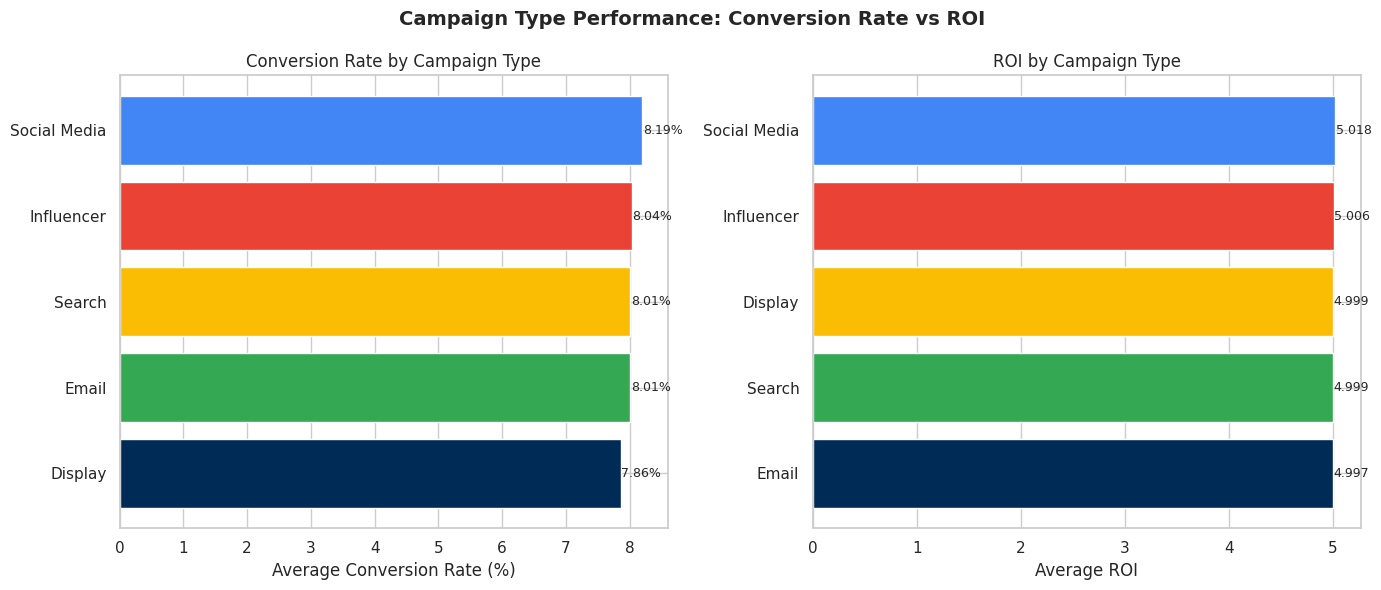

Chart saved as chart1_campaign_type.png


In [12]:
# Create a figure with 1 row and 2 columns of subplots (side-by-side charts)
# figsize sets the overall width and height of the figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Add a main title across the entire figure
fig.suptitle('Campaign Type Performance: Conversion Rate vs ROI',
             fontsize=14, fontweight='bold')

# Prepare summary statistics grouped by campaign type
# Calculate average conversion rate and ROI for each campaign type
ct_stats = df.groupby('Campaign_Type').agg(
    avg_cvr=('Conversion_Rate', 'mean'),
    avg_roi=('ROI', 'mean')
).reset_index().sort_values('avg_cvr', ascending=True)

# Define a custom color palette for the bars
colours = ['#002B56', '#34A853', '#FBBC04', '#EA4335', '#4285F4']

# --- Left chart: Conversion Rate by Campaign Type ---
bars1 = axes[0].barh(ct_stats['Campaign_Type'],   # Campaign types on the y-axis
                     ct_stats['avg_cvr'] * 100,   # Conversion rate converted to percentage
                     color=colours)
axes[0].set_xlabel('Average Conversion Rate (%)')
axes[0].set_title('Conversion Rate by Campaign Type')

# Add percentage labels to each bar
for bar, val in zip(bars1, ct_stats['avg_cvr']):
    axes[0].text(bar.get_width() + 0.01,          # Position label slightly to the right of the bar
                 bar.get_y() + bar.get_height()/2,
                 f'{val*100:.2f}%', va='center', fontsize=9)

# --- Right chart: ROI by Campaign Type ---
# Sort campaign types by ROI for clearer comparison
ct_roi = ct_stats.sort_values('avg_roi', ascending=True)
bars2 = axes[1].barh(ct_roi['Campaign_Type'],     # Campaign types on the y-axis
                     ct_roi['avg_roi'],           # Average ROI values
                     color=colours)
axes[1].set_xlabel('Average ROI')
axes[1].set_title('ROI by Campaign Type')

# Add ROI labels to each bar
for bar, val in zip(bars2, ct_roi['avg_roi']):
    axes[1].text(bar.get_width() + 0.005,         # Position label slightly to the right of the bar
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Save the figure as a PNG file with high resolution and display it
plt.savefig('chart1_campaign_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as chart1_campaign_type.png")


Finding 1: Social Media has the highest conversion rate at 8.19%.
And Social Media still leads on ROI, suggesting it generates returns
more efficiently per rand spent. This means that Social Media is the most efficient in campaign performance.

# Chart 2: Channel Performance Comparison

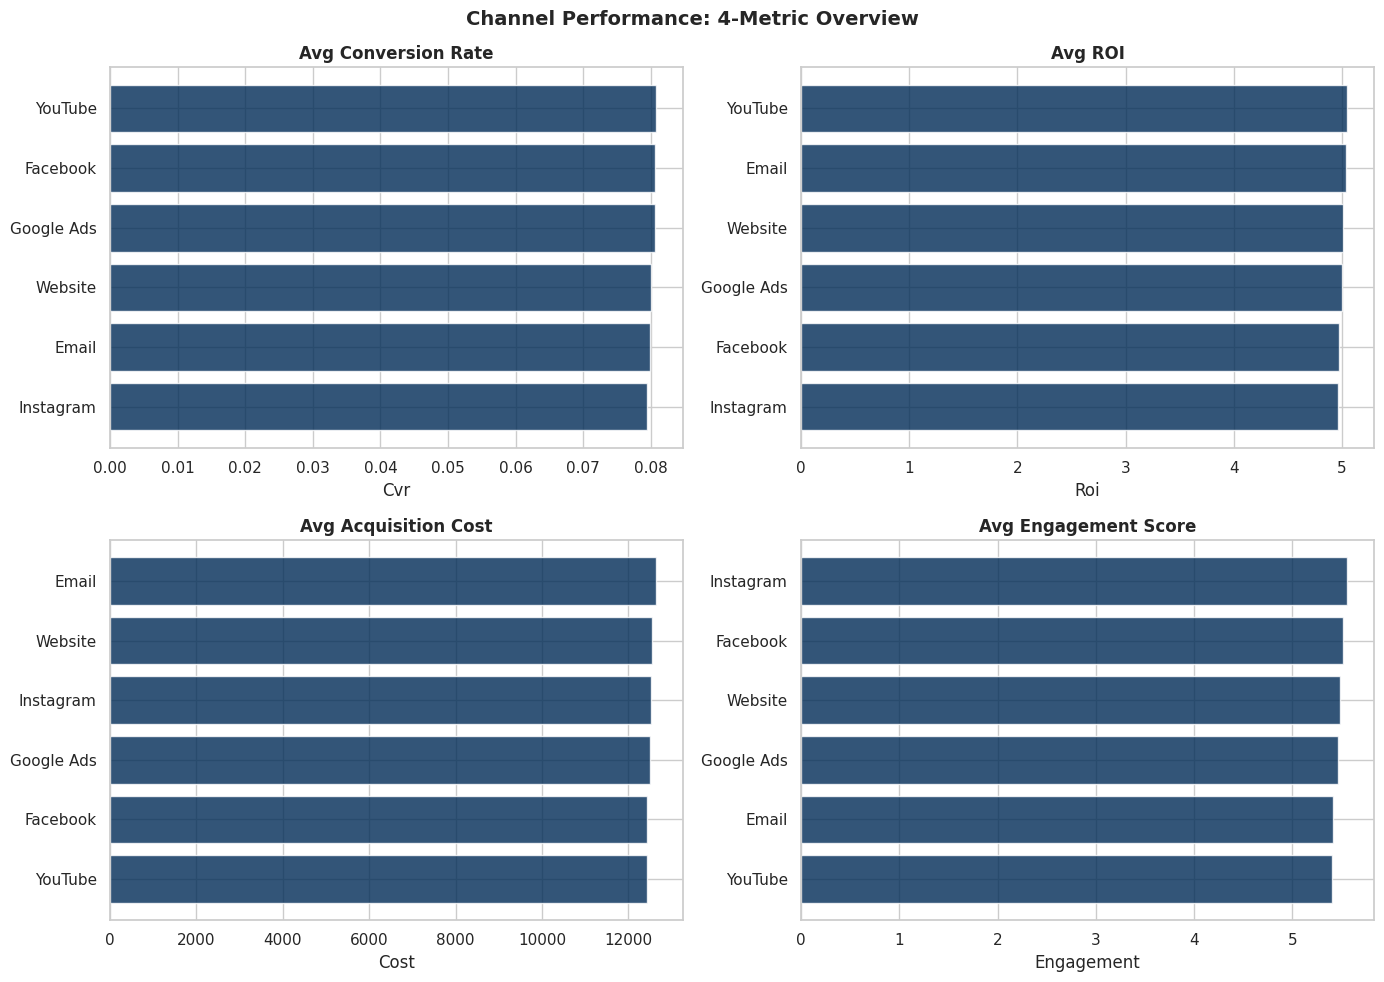

Chart saved as chart2_channel_performance.png


In [15]:
# Prepare summary statistics grouped by marketing channel
# Calculate average conversion rate, ROI, acquisition cost, and engagement score
ch_stats = df.groupby('Channel_Used').agg(
    avg_cvr=('Conversion_Rate', 'mean'),
    avg_roi=('ROI', 'mean'),
    avg_cost=('Acquisition_Cost', 'mean'),
    avg_engagement=('Engagement_Score', 'mean')
).reset_index().sort_values('avg_roi', ascending=False)  # Sort channels by ROI (highest first)

# Create a 2x2 grid of subplots (4 charts total)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Add a main title across the entire figure
fig.suptitle('Channel Performance: 4-Metric Overview', fontsize=14, fontweight='bold')

# Define the metrics to plot: each tuple contains
# (column name, chart title, subplot axis)
metrics = [
    ('avg_cvr', 'Avg Conversion Rate', axes[0,0]),
    ('avg_roi', 'Avg ROI', axes[0,1]),
    ('avg_cost', 'Avg Acquisition Cost', axes[1,0]),
    ('avg_engagement', 'Avg Engagement Score', axes[1,1])
]

# Loop through each metric and create a horizontal bar chart
for col, title, ax in metrics:
    # Sort data by the current metric for clearer comparison
    sorted_data = ch_stats.sort_values(col, ascending=True)

    # Create horizontal bars for each channel
    bars = ax.barh(sorted_data['Channel_Used'], sorted_data[col],
                   color='#002B56', alpha=0.8)

    # Set chart title and axis label
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col.replace('avg_', '').replace('_', ' ').title())  # Clean up label text

# Adjust layout to prevent overlapping titles/labels
plt.tight_layout()

# Save the figure as a PNG file with high resolution and display the charts
plt.savefig('chart2_channel_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart2_channel_performance.png")


Finding 2: YouTube demonstrates the highest average conversion rate and ROI, coupled with the lowest acquisition cost. Conversely, YouTube also has the lowest engagement rate, while Instagram leads in engagement.

# Chart 3: Audience Segment Heatmap

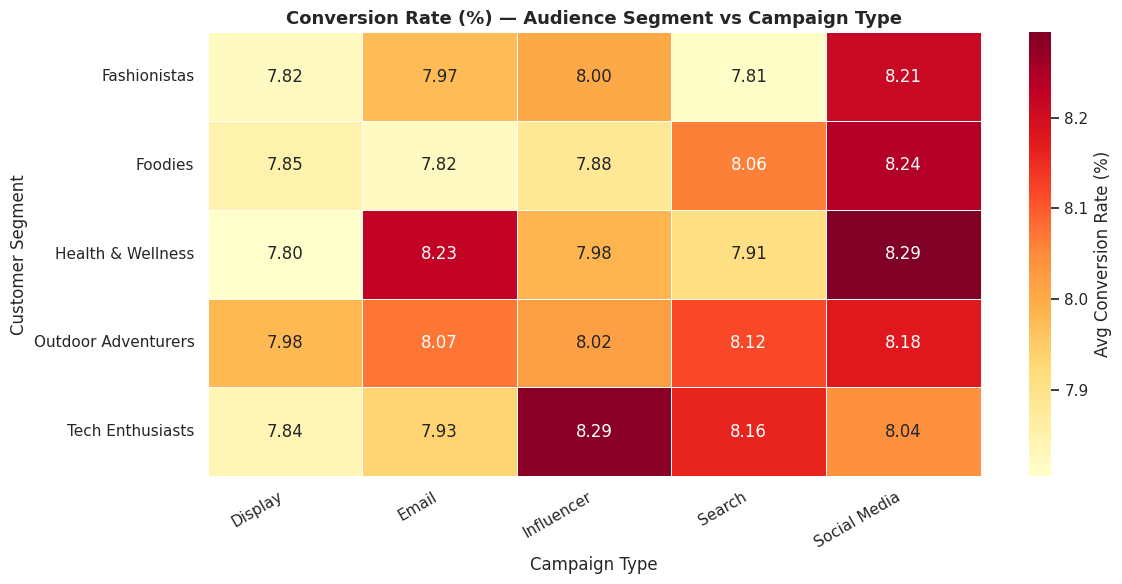

Chart saved as chart3_audience_heatmap.png


In [16]:
# Prepare data for the heatmap
# Group by both customer segment and campaign type
# Calculate the average conversion rate for each combination
# unstack() reshapes the data so campaign types become columns
heatmap_data = df.groupby(['Customer_Segment', 'Campaign_Type'])['Conversion_Rate'].mean().unstack()

# Create a figure and axis for the heatmap
fig, ax = plt.subplots(figsize=(12, 6))

# Draw the heatmap
sns.heatmap(
    heatmap_data * 100,                 # Multiply by 100 to show conversion rate as a percentage
    annot=True,                         # Display the values inside each cell
    fmt='.2f',                          # Format numbers with 2 decimal places
    cmap='YlOrRd',                      # Use yellow–orange–red color palette
    linewidths=0.5,                     # Add grid lines between cells
    ax=ax,                              # Plot on the defined axis
    cbar_kws={'label': 'Avg Conversion Rate (%)'}  # Label for the color bar
)

# Add titles and axis labels
ax.set_title('Conversion Rate (%) — Audience Segment vs Campaign Type',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Campaign Type')
ax.set_ylabel('Customer Segment')

# Rotate x-axis labels for readability
plt.xticks(rotation=30, ha='right')


plt.tight_layout()
plt.savefig('chart3_audience_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart3_audience_heatmap.png")


Finding 3: Social Media and Influencer campaigns achieve the highest conversion rates for Health & Wellness and Tech Enthusiast customer segments, averaging 8.29%. Conversely, Display campaigns targeting Health & Wellness yield the lowest conversion rate at 7.80%.

#  Chart 4: ROI Distribution by Campaign Type

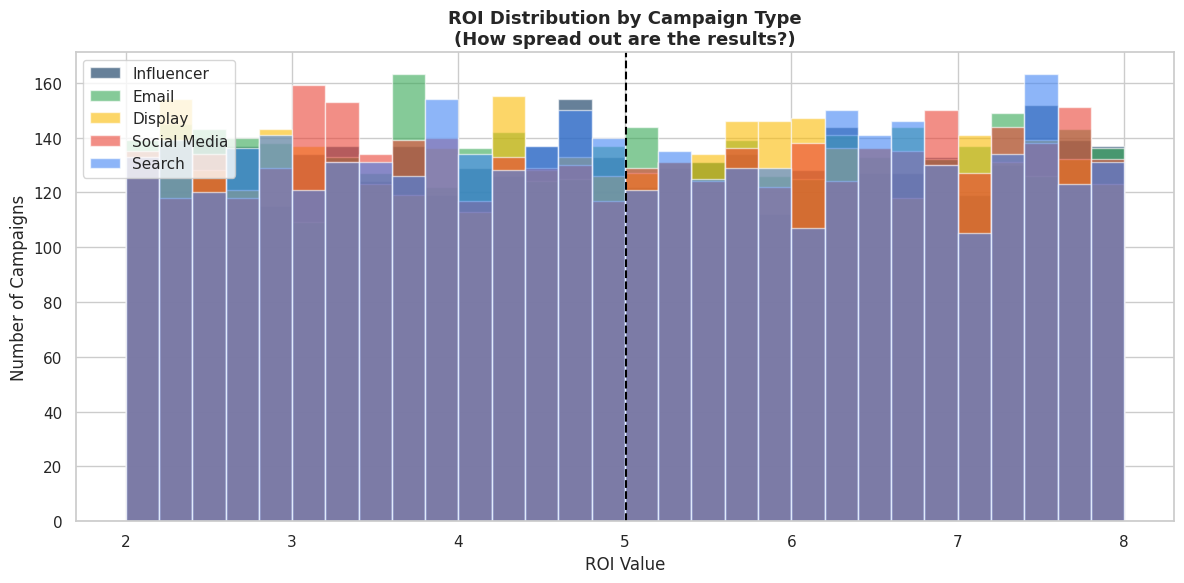

Chart saved as chart4_roi_distribution.png


In [17]:
# Create a figure and axis for the histogram
fig, ax = plt.subplots(figsize=(12, 6))

# Get the unique campaign types from the dataset
campaign_types = df['Campaign_Type'].unique()

# Define a color palette for the different campaign types
colours = ['#002B56', '#34A853', '#FBBC04', '#EA4335', '#4285F4']

# Loop through each campaign type and plot its ROI distribution
for i, ct in enumerate(campaign_types):
    # Filter the dataset for the current campaign type
    subset = df[df['Campaign_Type'] == ct]['ROI']

    # Plot a histogram of ROI values for this campaign type
    ax.hist(subset,
            bins=30,                          # Number of bins (intervals) for ROI values
            alpha=0.6,                        # Transparency so overlapping bars are visible
            label=ct,                         # Label for the legend
            color=colours[i % len(colours)],  # Cycle through colors
            edgecolor='white')                # White edges for clarity

# Add axis labels and chart title
ax.set_xlabel('ROI Value')
ax.set_ylabel('Number of Campaigns')
ax.set_title('ROI Distribution by Campaign Type\n(How spread out are the results?)',
             fontsize=13, fontweight='bold')

# Add a legend to distinguish campaign types
ax.legend()

# Draw a vertical dashed line showing the overall mean ROI across all campaigns
ax.axvline(df['ROI'].mean(),
           color='black',
           linestyle='--',
           linewidth=1.5,
           label=f'Overall Mean: {df["ROI"].mean():.3f}')

plt.tight_layout()
plt.savefig('chart4_roi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved as chart4_roi_distribution.png")


Finding 4: The ROI distributions across all campaign types (Influencer, Email, Display, Social Media, Search) are quite similar, with their average ROIs clustering tightly around the overall mean of 5.004. This suggests that, on average, no single campaign type significantly outperforms others in terms of raw ROI. However, the histograms visually demonstrate the spread and consistency of these returns, indicating that some campaign types might have slightly tighter or wider distributions, implying varying levels of risk or predictability in their ROI outcomes.

## Executive Summary

| Question | Finding | Recommendation |
|---|---|---|
| Which campaign type converts best? | Influencer | Prioritise influencer partnerships over broad awareness campaigns. |
| Which channel has best ROI? | YouTube | Increase content investment on YouTube. Long-form video builds audience trust and compounds over time through search |
| Which audience segment is most valuable? | Health & Wellness and Tech Enthusiasts | Build dedicated campaign funnels for these two segments separately. They have different pain points and messaging should not be blended. |
| Where is budget most wasted? | Display |Restrict Display to retargeting only. |

**Methodology:** 20,000-row sample from Manisha B's Marketing Campaign Performance
Dataset (Kaggle, ~200,000 rows). Sample drawn with random_state=42 for reproducibility.
Feature engineering: CTR calculated from Clicks/Impressions. ROI categories applied
as analyst-defined thresholds. All interpretations are original.

**How I used AI:** Used AI to help structure SQL query logic, then independently
modified queries to match actual column names and adapted questions to the dataset's
specific features. Chart styling and all analytical interpretations are my own.

In [18]:
from google.colab import files
files.download('chart1_campaign_type.png')
files.download('chart2_channel_performance.png')
files.download('chart3_audience_heatmap.png')
files.download('chart4_roi_distribution.png')

print("Charts downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Charts downloaded
